In [13]:
import pandas as pd
import yfinance as yf

raw = yf.download("PETR4.SA", start="2015-01-01", auto_adjust=True, progress=False) #usamos o auto_adjust=True pq o ajustado desconta dividendos, se usássemos False os valores de Close seriam diferentes
raw2 = yf.download("PETR4.SA", start="2015-01-01", auto_adjust=False, progress=False)

raw.head()

Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2015-01-02,2.344783,2.502605,2.342278,2.502605,49559500
2015-01-05,2.144375,2.302197,2.136859,2.289671,78385100
2015-01-06,2.074231,2.212013,2.014109,2.181951,84723300
2015-01-07,2.171931,2.186962,2.094273,2.144375,85531000
2015-01-08,2.312217,2.352299,2.189467,2.201992,83306300


In [6]:
print(f"Primeiro dia da tabela: {raw.index.min()}")
print(f"Último dia da tabela: {raw.index.max()}")
print(f"Linhas da tabela: {len(pd.bdate_range(raw.index.min(), raw.index.max()))}")

Primeiro dia da tabela: 2015-01-02 00:00:00
Último dia da tabela: 2026-09-11 00:00:00
Linhas da tabela: 3051


<Axes: title={'center': 'PETR4 sem ajuste'}, xlabel='Date'>

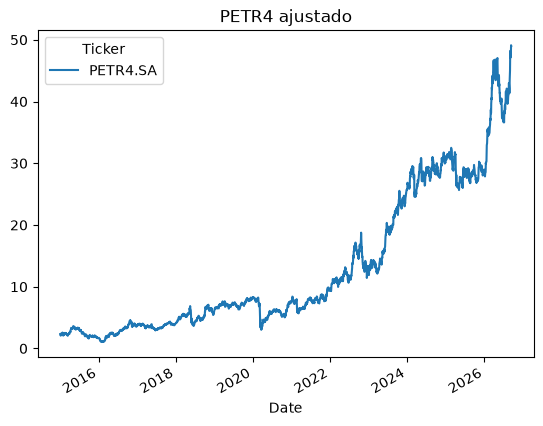

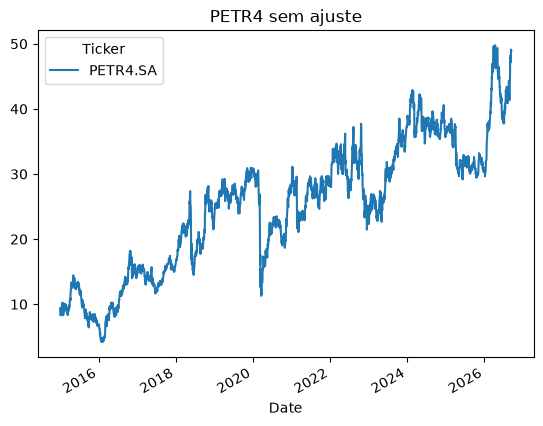

In [14]:
raw["Close"].plot(title="PETR4 ajustado")
raw2["Close"].plot(title="PETR4 sem ajuste")

In [16]:
TICKERS = ["PETR4","PETR3","VALE3","ITUB4","BBDC4","BBAS3","ABEV3","WEGE3",
           "B3SA3","RENT3","SUZB3","ELET3","PRIO3","RADL3","EQTL3","BPAC11",
           "ITSA4","LREN3","HAPV3","GGBR4","JBSS3","RAIL3","VIVT3","CSAN3",
           "EMBR3","TOTS3","CMIG4","BBSE3","ENEV3","SBSP3"]

raw = yf.download([t + ".SA" for t in TICKERS], start="2012-01-01", auto_adjust=True, progress=False)

prices = raw["Close"].copy()
prices.columns = [c.replace(".SA", "") for c in prices.columns]
prices.index = pd.DatetimeIndex(prices.index).tz_localize(None)
prices.shape

$JBSS3.SA: possibly delisted; no timezone found
$EMBR3.SA: possibly delisted; no timezone found
$ELET3.SA: possibly delisted; no timezone found

3 Failed downloads:
['JBSS3.SA', 'EMBR3.SA', 'ELET3.SA']: possibly delisted; no timezone found


(3652, 30)

In [ ]:
prices.isna().mean().sort_values(ascending=False).head(10) # Fração de NaN por ativo

ELET3     1.000000
EMBR3     1.000000
JBSS3     1.000000
HAPV3     0.429628
BPAC11    0.348850
RAIL3     0.219880
BBSE3     0.088719
BBDC4     0.000000
BBAS3     0.000000
CSAN3     0.000000
dtype: float64

<Axes: title={'center': 'Quantos ativos sem preço, por dia'}, xlabel='Date'>

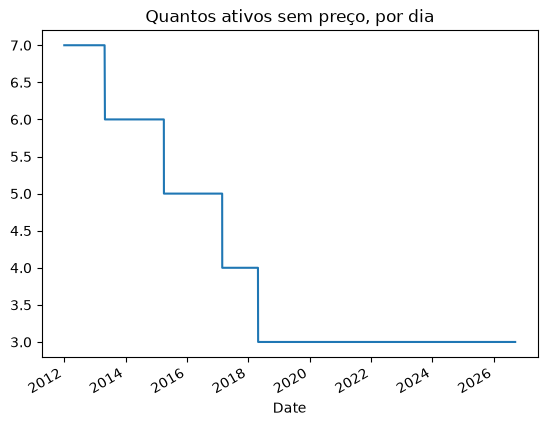

In [18]:
prices.isna().sum(axis=1).plot(title="Quantos ativos sem preço, por dia")

In [20]:
(prices.pct_change().abs() > 0.5).sum() # quantos dias com um retorno diário maior que 50% . Um retorno diário de 50% em ação é quase sempre um desdobramento mal ajustado

ABEV3     0
B3SA3     0
BBAS3     0
BBDC4     0
BBSE3     0
BPAC11    0
CMIG4     0
CSAN3     0
ELET3     0
EMBR3     0
ENEV3     0
EQTL3     0
GGBR4     0
HAPV3     0
ITSA4     0
ITUB4     0
JBSS3     0
LREN3     0
PETR3     0
PETR4     0
PRIO3     1
RADL3     0
RAIL3     0
RENT3     0
SBSP3     0
SUZB3     0
TOTS3     0
VALE3     0
VIVT3     0
WEGE3     0
dtype: int64

In [28]:
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

prices.to_parquet(RAW / "precos_brutos.parquet")